Analysis: NAVIGATION DOMAIN
Notebook 1 — Evidence Layer (GPS Signal Loss)

This notebook validates the raw telemetry evidence behind the GPS signal-loss use case.

The goal is to show that:
- signal changes are real,
- windows are deterministic,
- degraded GPS periods can be isolated,
- and the result is explainable evidence for the proposal.

We first validate one high-priority anchor from `nav_meta_log`, then inspect its local GPS telemetry window, and finally build state-based windows from `nav_segment_1`.

Data Sources:
- T1_GPS_SATS_DEGRADATION_RUN01.BIN
- 

Paths:
- ~/ardupilot-nav-domain-poc/bin/vault/df_source
- ~/ardupilot-nav-domain-poc/bin/vault/warehouse_df/NAV_20260319_1332_parts

1. Setup

In [27]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = os.path.abspath("../bin/vault/warehouse_df/NAV_20260319_1332_parts/nav_master.duckdb")
con = duckdb.connect(DB_PATH)

print("✅ Connected")

✅ Connected


Step 1: Pick anchor

In [28]:
anchor_df = con.execute("""
SELECT *
FROM nav_meta_log
WHERE rule_id = 'N-1'
LIMIT 1
""").df()

print("✅ Anchor loaded")
display(anchor_df)

✅ Anchor loaded


,mission_id,window_id,inode,TimeUS,rule_id,parameter,actual_value
0,NAV_20260319_1332,0.0,1,2444855,N-1,NSats,NaN


Step 2: Inspect telemetry window

In [29]:
window_df = con.execute("""
SELECT
    m.mission_id,
    s.TimeUS,
    s.NSats,
    s.HDOP
FROM nav_segment_1 AS s
JOIN nav_meta_log AS n
    ON s.inode = n.inode
JOIN mission_master AS m
    ON n.mission_id = m.mission_id
WHERE n.rule_id = 'N-1'
  AND s.msg_type = 'GPS'
  AND s.TimeUS BETWEEN n.TimeUS - 5000 AND n.TimeUS + 5000
LIMIT 50
""").df()

print(f"Rows in sample window: {len(window_df)}")
#display(window_df)

Rows in sample window: 50


Step 3: Validate window size + ranges

In [30]:
check_df = con.execute("""
SELECT
    COUNT(*) AS window_size,
    MIN(s.NSats) AS min_nsats,
    MAX(s.NSats) AS max_nsats,
    MIN(s.HDOP) AS min_hdop,
    MAX(s.HDOP) AS max_hdop
FROM nav_segment_1 AS s
JOIN nav_meta_log AS n
    ON s.inode = n.inode
WHERE n.rule_id = 'N-1'
  AND s.msg_type = 'GPS'
  AND s.TimeUS BETWEEN n.TimeUS - 5000 AND n.TimeUS + 5000
""").df()

print("✅ Window validation")
display(check_df)

✅ Window validation


,window_size,min_nsats,max_nsats,min_hdop,max_hdop
0,451,0.0,12.0,1.21,1.21


Step 3: Compute stats

In [31]:
stats_df = con.execute("""
SELECT
    m.mission_id,
    n.TimeUS AS anchor_time,
    MIN(s.TimeUS) AS start_time,
    MAX(s.TimeUS) AS end_time,
    COUNT(*) AS window_size,
    AVG(s.NSats) AS avg_nsats,
    AVG(s.HDOP) AS avg_hdop
FROM nav_segment_1 AS s
JOIN nav_meta_log AS n
    ON s.inode = n.inode
JOIN mission_master AS m
    ON n.mission_id = m.mission_id
WHERE n.rule_id = 'N-1'
  AND s.msg_type = 'GPS'
  AND s.TimeUS BETWEEN n.TimeUS - 5000 AND n.TimeUS + 5000
GROUP BY m.mission_id, n.TimeUS
""").df()

print("✅ Stats computed")
display(stats_df)

✅ Stats computed


,mission_id,anchor_time,start_time,end_time,window_size,avg_nsats,avg_hdop
0,NAV_20260319_1332,356399050,356399050,356399050,1264621,12.0,1.21
1,NAV_20260319_1332,345799125,345799125,345799125,1264621,12.0,1.21
2,NAV_20260319_1332,216979840,216979840,216979840,1264621,0.0,1.21
3,NAV_20260319_1332,53399465,53399465,53399465,1264621,0.0,1.21
4,NAV_20260319_1332,449599255,449599255,449599255,1264621,12.0,1.21
...,...,...,...,...,...,...,...
446,NAV_20260319_1332,22199450,22199450,22199450,1264621,0.0,1.21
447,NAV_20260319_1332,449999095,449999095,449999095,1264621,12.0,1.21
448,NAV_20260319_1332,438199650,438199650,438199650,1264621,12.0,1.21
449,NAV_20260319_1332,365599535,365599535,365599535,1264621,12.0,1.21


Load full NSats signal

In [32]:
df = con.execute("""
SELECT TimeUS, NSats
FROM nav_segment_1
WHERE NSats IS NOT NULL
ORDER BY TimeUS
""").df()

print(f"Rows loaded: {len(df)}")

if df.empty:
    raise ValueError("No data")

display(df.head())

Rows loaded: 451


,TimeUS,NSats
0,10999765,0.0
1,11199685,0.0
2,11399605,0.0
3,11599525,0.0
4,11799445,0.0


Sanity check

In [33]:
print(df["TimeUS"].min(), "→", df["TimeUS"].max())

unique_nsats = sorted(df["NSats"].dropna().unique())
print("NSats values:", unique_nsats)

10999765 → 449999095
NSats values: [np.float64(0.0), np.float64(7.0), np.float64(12.0)]


Build windows (core logic)

In [34]:
df["prev"] = df["NSats"].shift()
df["change"] = (df["NSats"] != df["prev"]).astype(int)
df["window_id"] = df["change"].cumsum()

print("Total windows:", df["window_id"].nunique())

Total windows: 5


Aggregate windows

In [35]:
windows = df.groupby("window_id").agg(
    start_time=("TimeUS", "min"),
    end_time=("TimeUS", "max"),
    nsats=("NSats", "first"),
    count=("TimeUS", "count")
).reset_index()

windows["duration_sec"] = (windows["end_time"] - windows["start_time"]) / 1e6

print("Windows created:", len(windows))
display(windows.head())

Windows created: 5


,window_id,start_time,end_time,nsats,count,duration_sec
0,1,10999765,252199080,0.0,254,241.199315
1,2,260799805,404379850,12.0,146,143.580045
2,3,406599795,416999800,7.0,12,10.400005
3,4,417199720,427999565,0.0,13,10.799845
4,5,428199485,449999095,12.0,26,21.799610


Detect degradation

In [36]:
degraded = windows[windows["nsats"] <= 6]

print("Degraded windows:", len(degraded))
display(degraded.head())

Degraded windows: 2


,window_id,start_time,end_time,nsats,count,duration_sec
0,1,10999765,252199080,0.0,254,241.199315
3,4,417199720,427999565,0.0,13,10.799845


Plot

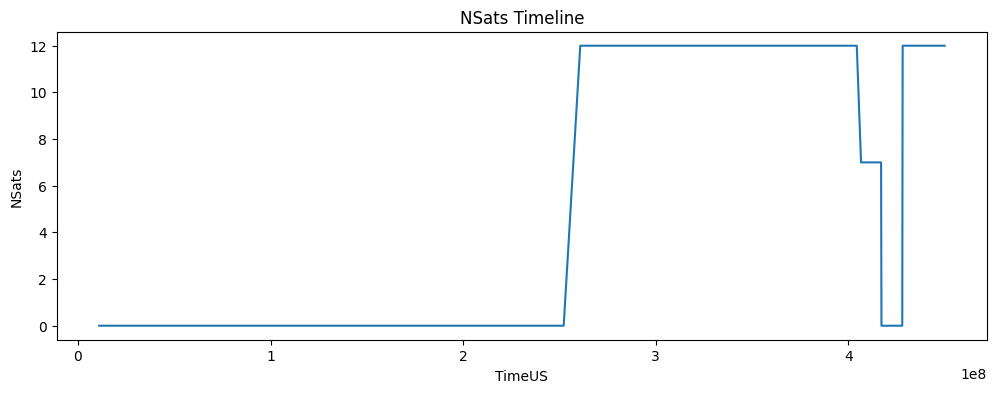

In [37]:
plt.figure(figsize=(12,4))
plt.plot(df["TimeUS"], df["NSats"])
plt.title("NSats Timeline")
plt.xlabel("TimeUS")
plt.ylabel("NSats")
plt.show()

Mission Summary — GPS Signal Loss Analysis
This section summarizes the full mission behavior using descriptive statistics derived from the evidence layer.
Processing Flow
- .BIN generated via SITL (`test_gps_loss.py` using `SIM_GPS1_NUMSATS`)
- Processed through DF Pipeline:<br>
  `BIN → ingestion → shards → NAV master → DuckDB → analysis → final output`
Observed Anomaly Pattern
- Baseline: 12 satellites (normal navigation)
- Degraded: 7 satellites (reduced signal)
- Loss: 0 satellites (complete outage)
- Recovery: 12 satellites (signal restored)
Key Questions Answered
- When did degradation occur?
- How long did each phase last?
- Was the event noise or sustained failure?
- Is recovery clean and complete?

Code (Mission Stats)

In [38]:
# Total mission time
start = df["TimeUS"].min()
end = df["TimeUS"].max()
mission_duration = (end - start) / 1e6

# NSats distribution
nsat_counts = df["NSats"].value_counts().sort_index()

# Window classification
def classify(n):
    if n == 0:
        return "LOSS"
    elif n <= 6:
        return "DEGRADED"
    else:
        return "HEALTHY"

windows["status"] = windows["nsats"].apply(classify)

status_counts = windows["status"].value_counts()

# Averages
avg_nsats = df["NSats"].mean()

print("✅ Mission Stats Computed")

✅ Mission Stats Computed


Display Summary

In [39]:
print("\n=== Mission Runtime ===")
print(f"Start: {start}")
print(f"End: {end}")
print(f"Duration (sec): {mission_duration:.2f}")

print("\n=== NSats Distribution ===")
print(nsat_counts)

print("\n=== Average NSats ===")
print(round(avg_nsats, 2))

print("\n=== Window Status Counts ===")
print(status_counts)

print("\n=== Total Windows ===")
print(len(windows))


=== Mission Runtime ===
Start: 10999765
End: 449999095
Duration (sec): 439.00

=== NSats Distribution ===
NSats
0.0     267
7.0      12
12.0    172
Name: count, dtype: int64

=== Average NSats ===
4.76

=== Window Status Counts ===
status
HEALTHY    3
LOSS       2
Name: count, dtype: int64

=== Total Windows ===
5


Mission Scorecard — GPS Signal Health
This scorecard converts raw evidence into a quantitative evaluation of mission health.
Metrics:
- Signal Stability
- Degradation Severity
- GPS Availability
- Recovery Quality
Each metric is computed deterministically from telemetry windows.

In [40]:
# --- Total duration
total_duration = windows["duration_sec"].sum()

# --- Duration by status
durations = windows.groupby("status")["duration_sec"].sum()

healthy_dur = durations.get("HEALTHY", 0)
degraded_dur = durations.get("DEGRADED", 0)
loss_dur = durations.get("LOSS", 0)

# --- Scores (0–100)

# 1. Availability (how much time GPS was usable)
availability_score = (healthy_dur / total_duration) * 100

# 2. Degradation penalty
degradation_score = 100 - ((degraded_dur + loss_dur) / total_duration) * 100

# 3. Stability (fewer windows = more stable)
stability_score = 100 - (len(windows) * 2)   # simple penalty model
stability_score = max(stability_score, 0)

# 4. Recovery (did we return to healthy at end?)
recovery_score = 100 if windows.iloc[-1]["status"] == "HEALTHY" else 50

print("✅ Scorecard computed")

✅ Scorecard computed


Display Scorecard

In [41]:
print("\n=== Mission Scorecard ===")

print(f"GPS Availability Score : {availability_score:.2f}")
print(f"Degradation Score      : {degradation_score:.2f}")
print(f"Signal Stability Score : {stability_score:.2f}")
print(f"Recovery Score         : {recovery_score:.2f}")


=== Mission Scorecard ===
GPS Availability Score : 41.09
Degradation Score      : 41.09
Signal Stability Score : 90.00
Recovery Score         : 100.00


Final Report — GPS Signal Loss Evidence
This section consolidates all outputs into a structured report.
Sections:
1. Anchor Evidence
2. Window Validation
3. Signal Windows
4. Degradation Detection
5. Mission Summary
6. Scorecard
This represents the full evidence → diagnosis flow.

In [42]:
report = {
    "anchor": anchor_df.to_dict(orient="records"),

    "window_validation": check_df.to_dict(orient="records"),

    "window_stats": stats_df.to_dict(orient="records"),

    "degraded_windows": degraded.head(5).to_dict(orient="records"),

    "mission_summary": {
        "start_time": int(start),
        "end_time": int(end),
        "duration_sec": round(mission_duration, 2),
        "avg_nsats": round(avg_nsats, 2),
        "nsats_distribution": nsat_counts.to_dict(),
        "window_status_counts": status_counts.to_dict(),
        "total_windows": int(len(windows))
    },

    "scorecard": {
        "availability": round(availability_score, 2),
        "degradation": round(degradation_score, 2),
        "stability": round(stability_score, 2),
        "recovery": recovery_score
    }
}

print("✅ Report built")

✅ Report built


Display

In [43]:
from pprint import pprint

print("\n=== 1. Anchor Evidence ===")
pprint(report["anchor"][:5])

print("\n=== 2. Window Validation ===")
pprint(report["window_validation"][:5])

print("\n=== 3. Window Stats ===")
pprint(report["window_stats"][:5])

print("\n=== 4. Degraded Windows (sample) ===")
pprint(report["degraded_windows"])

print("\n=== 5. Mission Summary ===")
pprint(report["mission_summary"])

print("\n=== 6. Scorecard ===")
pprint(report["scorecard"])


=== 1. Anchor Evidence ===
[{'TimeUS': 2444855,
  'actual_value': nan,
  'inode': 1,
  'mission_id': 'NAV_20260319_1332',
  'parameter': 'NSats',
  'rule_id': 'N-1',
  'window_id': 0.0}]

=== 2. Window Validation ===
[{'max_hdop': 1.21,
  'max_nsats': 12.0,
  'min_hdop': 1.21,
  'min_nsats': 0.0,
  'window_size': 451}]

=== 3. Window Stats ===
[{'anchor_time': 356399050,
  'avg_hdop': 1.2100000000007083,
  'avg_nsats': 12.0,
  'end_time': 356399050,
  'mission_id': 'NAV_20260319_1332',
  'start_time': 356399050,
  'window_size': 1264621},
 {'anchor_time': 345799125,
  'avg_hdop': 1.2100000000007083,
  'avg_nsats': 12.0,
  'end_time': 345799125,
  'mission_id': 'NAV_20260319_1332',
  'start_time': 345799125,
  'window_size': 1264621},
 {'anchor_time': 216979840,
  'avg_hdop': 1.2100000000007083,
  'avg_nsats': 0.0,
  'end_time': 216979840,
  'mission_id': 'NAV_20260319_1332',
  'start_time': 216979840,
  'window_size': 1264621},
 {'anchor_time': 53399465,
  'avg_hdop': 1.21000000000070